In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lifelines

In [2]:
BATCH_SIZE = 100_000
SEED = 37
SAMPLE_PROPORTION = 0.0005 

In [3]:
member_batches = []
max_index = 0

for batch in pd.read_csv('../data/members_v3.csv', chunksize = BATCH_SIZE):
    member_batches.append(batch.sample(frac = SAMPLE_PROPORTION, random_state = SEED))
    if max(batch.index) + 1 > max_index:
        max_index = max(batch.index) + 1

sample_members = pd.concat(member_batches, ignore_index = True)
member_ids = set(sample_members['msno'])

print(f'{len(sample_members): ,} out of {max_index: ,} members selected.')
print()
print(sample_members.head())
print()
print(sample_members.info())

 3,385 out of  6,769,473 members selected.

                                           msno  city  bd  gender  \
0  59LT0TXKCMT0x8lBV6lihO8CvTZ9z5Sb9UsypwfC6Uk=     1   0     NaN   
1  +9WO11eKjgcyXUN4ewrT4Q00zTKY/fHbZgYaxZsSDt8=     1   0     NaN   
2  6P/ta5JtN8UDFiuHI2ELWXLaRUsgN97Zj63QAMWLycQ=     1   0     NaN   
3  0g6qJ7am8vecp54eFV7I0ceLy8yzHWJA0a32aNZM6YU=     1  21  female   
4  LVZhPn7ds6KtnZ1GPMHV4DFhCuYAiQtf4QucKYL2d9A=     1   0     NaN   

   registered_via  registration_init_time  
0               4                20161202  
1               9                20120208  
2               4                20161206  
3               3                20150414  
4               9                20150919  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3385 entries, 0 to 3384
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   msno                    3385 non-null   object
 1   city     

In [4]:
sample_members_typecast = sample_members.copy()

sample_members_typecast[['city', 'registered_via']] = sample_members_typecast[['city', 'registered_via']].astype('object')
sample_members_typecast['registration_init_time'] = pd.to_datetime(sample_members_typecast['registration_init_time'], format = '%Y%m%d')

print(sample_members_typecast.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3385 entries, 0 to 3384
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   msno                    3385 non-null   object        
 1   city                    3385 non-null   object        
 2   bd                      3385 non-null   int64         
 3   gender                  1151 non-null   object        
 4   registered_via          3385 non-null   object        
 5   registration_init_time  3385 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 158.8+ KB
None


In [5]:
transaction_batches = []

max_index_total = 0
for csv in ['../data/transactions.csv', '../data/transactions_v2.csv']:
    max_index = 0
    for batch in pd.read_csv(csv, chunksize = BATCH_SIZE):
        transaction_batches.append(batch[batch['msno'].isin(member_ids)])
        if max(batch.index) + 1 > max_index:
            max_index = max(batch.index) + 1
    max_index_total += max_index
    
sample_transactions = pd.concat(transaction_batches, ignore_index = True)

print(f'{len(sample_transactions): ,} out of {max_index_total: ,} transactions selected.')
print()
print(sample_transactions.head())
print()
print(sample_transactions.info())

 10,056 out of  22,978,755 transactions selected.

                                           msno  payment_method_id  \
0  wcXslluldERi48gljH+9o9KgXgYsCt5ih8+i3EXUNIE=                 34   
1  mCQIOwBybuLG6L88zC65GiNd5jihPflNq03KWRYbA+c=                 40   
2  qaT4OYJ+gEbriiBlR29k4BUJeszVX8VxapTeUuO0xa4=                 40   
3  pW3ywgOqWZkR2vrSJKz+j6T8NuC0Msi6Q6XZdZMMDwE=                 39   
4  nBkJ6ORyG8iptHWFrP4/4e4AVkIWnVCklerE8JpQQK8=                 39   

   payment_plan_days  plan_list_price  actual_amount_paid  is_auto_renew  \
0                 30              149                 149              1   
1                 30              149                 149              1   
2                 30              149                 149              1   
3                 30              149                 149              1   
4                 30              149                 149              1   

   transaction_date  membership_expire_date  is_cancel  
0          201

In [6]:
sample_transactions_typecast = sample_transactions.copy()

sample_transactions_typecast['payment_method_id'] = sample_transactions_typecast['payment_method_id'].astype('object')
for column in ['transaction_date', 'membership_expire_date']:
    sample_transactions_typecast[column] = pd.to_datetime(sample_transactions_typecast[column], format = '%Y%m%d')
sample_transactions_typecast[['is_auto_renew', 'is_cancel']] = sample_transactions_typecast[['is_auto_renew', 'is_cancel']].astype('boolean')

print(sample_transactions_typecast.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10056 entries, 0 to 10055
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   msno                    10056 non-null  object        
 1   payment_method_id       10056 non-null  object        
 2   payment_plan_days       10056 non-null  int64         
 3   plan_list_price         10056 non-null  int64         
 4   actual_amount_paid      10056 non-null  int64         
 5   is_auto_renew           10056 non-null  boolean       
 6   transaction_date        10056 non-null  datetime64[ns]
 7   membership_expire_date  10056 non-null  datetime64[ns]
 8   is_cancel               10056 non-null  boolean       
dtypes: boolean(2), datetime64[ns](2), int64(3), object(2)
memory usage: 589.3+ KB
None


The oldest verified age in Taiwan is 111 years. Therefore, we assume that any of the ages between 1 and 111 are truthful, and ages outside that range are set to null.

In [7]:
sample = pd.merge(sample_members_typecast, sample_transactions_typecast, how = 'inner').drop_duplicates()\
    .drop(columns = ['payment_plan_days', 'plan_list_price', 'is_auto_renew'])

In [8]:
print(((sample['bd'] <= 0) | (sample['bd'] > 111)).mean())
print((sample['actual_amount_paid'] < 0).mean())
print(sample['gender'].unique())

0.4761289039188383
0.0
['male' 'female' nan]


In [9]:
sample2 = sample.copy()
sample2['bd'] = [None if x <= 0 or x > 111 else x for x in sample2['bd']]
print(sample2.info())

<class 'pandas.core.frame.DataFrame'>
Index: 10054 entries, 0 to 10055
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   msno                    10054 non-null  object        
 1   city                    10054 non-null  object        
 2   bd                      5267 non-null   float64       
 3   gender                  5257 non-null   object        
 4   registered_via          10054 non-null  object        
 5   registration_init_time  10054 non-null  datetime64[ns]
 6   payment_method_id       10054 non-null  object        
 7   actual_amount_paid      10054 non-null  int64         
 8   transaction_date        10054 non-null  datetime64[ns]
 9   membership_expire_date  10054 non-null  datetime64[ns]
 10  is_cancel               10054 non-null  boolean       
dtypes: boolean(1), datetime64[ns](3), float64(1), int64(1), object(5)
memory usage: 883.7+ KB
None


In [10]:
print('proportion of missing \'bd\' and \'gender\':')
print(((sample2['bd'].isna()) & (sample2['gender'].isna())).mean())
print()
print('proportion of missing \'bd\' only:')
print(((sample2['bd'].isna()) & (~ sample2['gender'].isna())).mean())
print()
print('proportion of missing \'gender\' only:')
print(((sample2['gender'].isna()) & (~ sample2['bd'].isna())).mean())

proportion of missing 'bd' and 'gender':
0.46667992838671174

proportion of missing 'bd' only:
0.009448975532126517

proportion of missing 'gender' only:
0.010443604535508256


In [11]:
sample3 = sample2.copy()

sample3['membership_expire_date'] = np.where(sample3['is_cancel'], sample3['transaction_date'], sample3['membership_expire_date'])

print((sample3['membership_expire_date'] < sample3['transaction_date']).mean())

sample3 = sample3[sample3['membership_expire_date'] >= sample3['transaction_date']].reset_index(drop = True)

print((sample3['membership_expire_date'] < sample3['transaction_date']).mean())

0.0007957032027053909
0.0


In [12]:
OBS_START = pd.to_datetime(20150101, format = '%Y%m%d')
OBS_END = pd.to_datetime(20170331, format = '%Y%m%d')

In [13]:
survival = sample3.copy().sort_values(by = ['msno', 'transaction_date'])

survival['start'] = (survival['transaction_date'] - survival['registration_init_time']).dt.days + 1
survival['end'] = [d if d < OBS_END else OBS_END for d in survival['membership_expire_date']]
survival['end'] = (survival['end'] - survival['registration_init_time']).dt.days + 1
survival['obs_end'] = (OBS_END - survival['registration_init_time']).dt.days + 1

survival['is_last_obs'] = survival.groupby('msno')['start'].transform(lambda x: x == x.max())
survival['event'] = (
    ((survival['end'] + 30 < survival['start'].shift(-1)) & (survival['msno'] == survival['msno'].shift(-1))) |
    ((survival['is_last_obs']) & (survival['end'] + 30 < survival['obs_end']))
)

survival['event_num'] = survival.groupby('msno')['event'].cumsum()
survival['tenure'] = survival.groupby('msno')['event_num'].shift(1, fill_value = 0) + 1

survival = survival\
    .groupby(['msno', 'tenure', 'city', 'bd', 'gender', 'registered_via', 'payment_method_id'])\
    .agg({
        'actual_amount_paid': 'sum',
        'start': 'min',
        'end': 'max',
        'event': 'last'
    })\
    .reset_index()

survival['time'] = survival['end'] - survival['start'] + 1
print(survival.head())

                                           msno  tenure  city    bd  gender  \
0  ++bQ/m6G+0XALmzX6fVXZmJkTBL95sxh166sI/METug=       1    13  30.0    male   
1  +7M4UyB4p3qWZ93IFTdgyz39JkUVH2IimhOLeZifO3g=       1     4  22.0    male   
2  +CzHhLr8g3bQ8usak5QnzmzibRsEXtQ0c1hfZsv9c/w=       1     5  43.0    male   
3  +CzHhLr8g3bQ8usak5QnzmzibRsEXtQ0c1hfZsv9c/w=       2     5  43.0    male   
4  +URN/1QbvZuUQWRZQcyctq5DDLlvkU/FpQASfWP/gaQ=       1    22  25.0  female   

   registered_via  payment_method_id  actual_amount_paid  start   end  event  \
0               9                 32                3576   3328  3769  False   
1               4                 38                 298      3    67   True   
2               9                 39                1788   2792  3194   True   
3               9                 39                1341   3339  3582  False   
4               9                 39                1788   1756  2177   True   

   time  
0   442  
1    65  
2   403  
3   

168.0


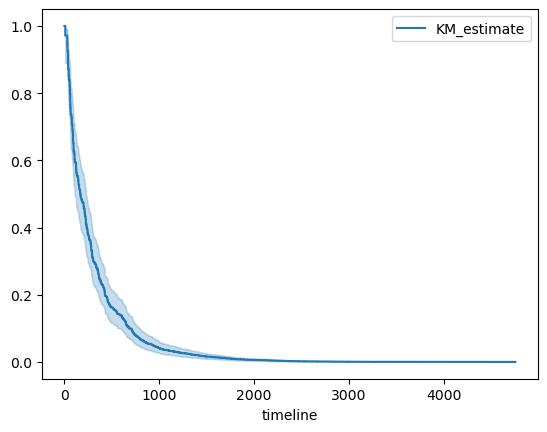

In [14]:
kmf = lifelines.KaplanMeierFitter()
kmf.fit(survival['end'], survival['event'], entry = survival['start'])
print(kmf.median_survival_time_)
kmf.plot()
plt.show()